# Notebook 06: Due Diligence & Systematics

**Purpose:** Stress-test the empirical findings of the Rational Taper to confirm that the physical insights ($g(R_t) \approx a_0/2$, the handover point, and the additive coupling) are independent physical realities — not artifacts of the fitting process or biases in the SPARC dataset.

Four tests are executed:

| Test | Threat | Pass Condition |
|---|---|---|
| **A: $R_t$ vs $R_{\rm max}$** | $R_t$ is pushed to the data boundary by the optimizer | Substantial fraction of galaxies have $R_t < R_{\rm max}$ |
| **B: Surface Brightness Independence** | $g(R_t) \approx a_0/2$ is a coincidental average, not universal | Flat trend of $g(R_t)$ vs SB and vs baryonic mass (slope $p > 0.05$) |
| **C: Baryon Fraction Residuals** | Additive coupling fails in baryon-dominated or missing-mass-dominated regions | Rational Taper fractional residuals flat in $f_{\rm bary}$ |
| **D: Quality Stratification** | BIC wins are padded by low-quality (Q=3) galaxies | RT win rate maintained or improved in Q=1 (highest quality) |

**Prerequisites:** Run `notebooks/00_setup.ipynb` first.

In [9]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.database import get_session, init_db, query_fits_as_dataframe
from src.physics import compute_transition_diagnostics, compute_total_model_velocity, A0_MOND
from src.utils import get_project_root, setup_logger

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

logger = setup_logger('notebook_06')
project_root = get_project_root()
engine = init_db()
session = get_session(engine)

FIGURES_DIR = project_root / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

A0_HALF = A0_MOND / 2.0
print(f'Setup complete.  a\u2080 = {A0_MOND:.4f} km\u00b2/s\u00b2/kpc,  a\u2080/2 = {A0_HALF:.4f}')

2026-03-13 15:47:23 | INFO     | src.database | Database initialized at C:\Projects\ISM\tapered-model-comparison\data\processed\galaxy_dynamics.db


Setup complete.  a₀ = 3703.0000 km²/s²/kpc,  a₀/2 = 1851.5000


## Data Load

All DB queries are performed here in bulk to avoid repeated round-trips in later cells.

In [10]:
# Bulk-load all radial profiles
all_profiles = pd.read_sql(
    'SELECT galaxy_id, radius_kpc, v_obs, v_baryon_total FROM radial_profiles '
    'ORDER BY galaxy_id, radius_kpc',
    engine
)

# Galaxy metadata
gal_meta = pd.read_sql(
    'SELECT galaxy_id, quality_flag, sb_disk, luminosity_band_36, r_disk_kpc FROM galaxies',
    engine
)

# All model fits
fits_df = query_fits_as_dataframe(session)

# Rational Taper fits only (converged)
rt_fits = fits_df[
    (fits_df['model_name'] == 'rational_taper') & (fits_df['converged'] == True)
].copy()
rt_fits = rt_fits.rename(columns={'param1': 'omega', 'param2': 'R_t'})

# BIC pivot for ΔBIC analysis (Test D)
bic_wide = fits_df.pivot_table(
    index='galaxy_id', columns='model_name', values='bic', aggfunc='first'
).rename(columns={
    'nfw':            'bic_nfw',
    'mond_fixed':     'bic_mond_fixed',
    'mond_free':      'bic_mond_free',
    'rational_taper': 'bic_rt',
})
bic_complete = bic_wide.dropna().copy()
bic_complete['delta_nfw'] = bic_complete['bic_nfw'] - bic_complete['bic_rt']

bic_cols = ['bic_nfw', 'bic_mond_fixed', 'bic_mond_free', 'bic_rt']
bic_complete['winner'] = bic_complete[bic_cols].idxmin(axis=1)
label_map = {
    'bic_nfw':        'NFW',
    'bic_mond_fixed': 'MOND (fixed)',
    'bic_mond_free':  'MOND (free)',
    'bic_rt':         'Rational Taper',
}
bic_complete['winner_label'] = bic_complete['winner'].map(label_map)
bic_complete = bic_complete.reset_index().merge(gal_meta[['galaxy_id', 'quality_flag']], on='galaxy_id', how='left')

print(f'Profiles: {len(all_profiles)} rows, {all_profiles["galaxy_id"].nunique()} galaxies')
print(f'Galaxy metadata: {len(gal_meta)} rows')
print(f'Fit rows: {len(fits_df)}  |  RT converged: {len(rt_fits)}')
print(f'BIC-complete galaxies: {len(bic_complete)}')

Profiles: 3391 rows, 175 galaxies
Galaxy metadata: 175 rows
Fit rows: 700  |  RT converged: 175
BIC-complete galaxies: 175


---
## Test A: Extrapolation Artifact Check ($R_t$ vs $R_{\rm max}$)

**Threat:** The optimizer may push $R_t$ to the outer edge of the data ($R_{\rm max}$) because it has no information beyond that point. If $R_t \approx R_{\rm max}$ for most galaxies, the transition is not a physically detected scale — it is merely the boundary of the telescope map.

**Pass condition:** A substantial fraction of galaxies should have $R_t < R_{\rm max}$, demonstrating the model is detecting a transition *within* the visible disk.

In [11]:
# Maximum observed radius per galaxy
r_max_df = all_profiles.groupby('galaxy_id')['radius_kpc'].max().reset_index()
r_max_df.columns = ['galaxy_id', 'r_max_kpc']

# Merge with RT fits
test_a = rt_fits[['galaxy_id', 'R_t']].merge(
    r_max_df, on='galaxy_id', how='inner'
).merge(
    gal_meta[['galaxy_id', 'quality_flag']], on='galaxy_id', how='left'
)
test_a = test_a.dropna(subset=['R_t', 'r_max_kpc'])

n_inside = int((test_a['R_t'] < test_a['r_max_kpc']).sum())
n_total  = len(test_a)
pct_inside = 100.0 * n_inside / n_total
ratio_median = (test_a['R_t'] / test_a['r_max_kpc']).median()

print(f'=== Test A: Rₜ vs R_max ===')
print(f'Galaxies with R_t < R_max:  {n_inside} / {n_total}  ({pct_inside:.1f}%)')
print(f'Median R_t / R_max ratio:   {ratio_median:.3f}')
print(f'(Ratio < 1.0 indicates R_t is interior to the data)')
if pct_inside >= 50:
    print('PASS — majority of R_t values lie within the observed disk')
else:
    print('CAUTION — fewer than half of R_t values are interior to R_max')

=== Test A: Rₜ vs R_max ===
Galaxies with R_t < R_max:  123 / 175  (70.3%)
Median R_t / R_max ratio:   0.341
(Ratio < 1.0 indicates R_t is interior to the data)
PASS — majority of R_t values lie within the observed disk


Saved: C:\Projects\ISM\tapered-model-comparison\results\figures\06_rt_vs_rmax_dual.png


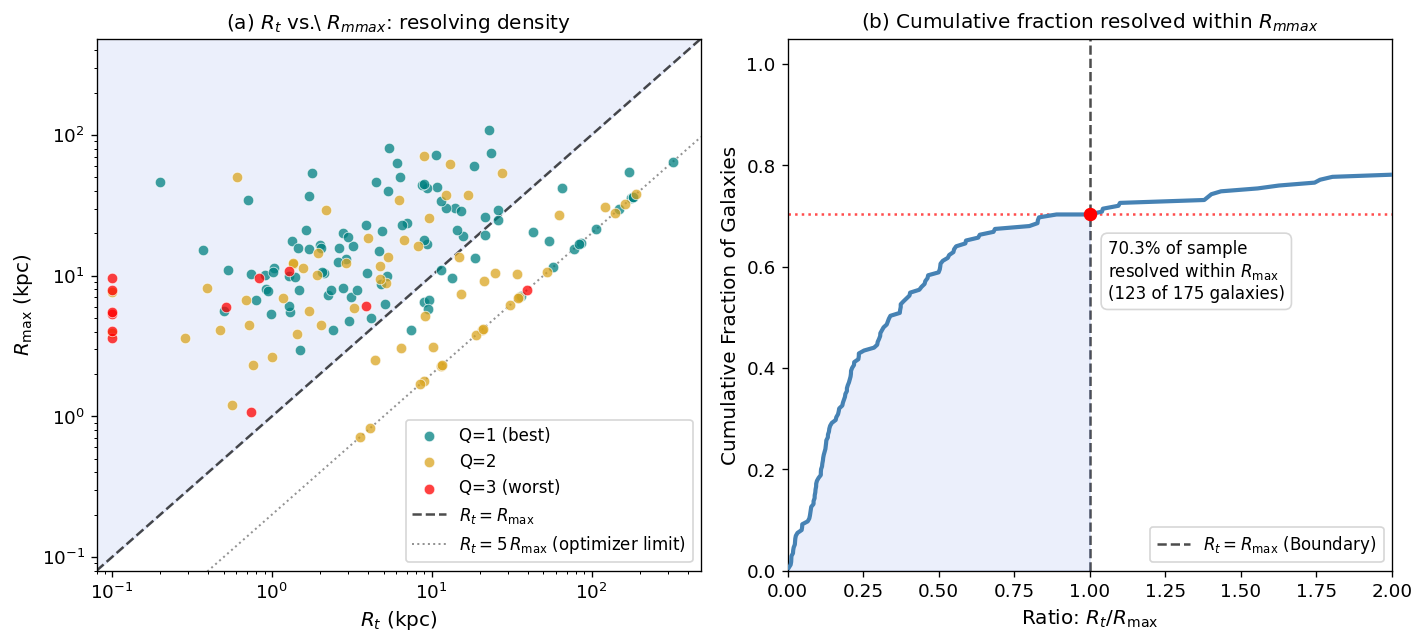

In [12]:
# ── Test A: Plotting (Dual Panel) ──────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

# Calculate the ratio for the CDF
test_a['ratio'] = test_a['R_t'] / test_a['r_max_kpc']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))

# --- Panel 1: Log-Log Scatter ---
qflag_colors = {1: 'teal', 2: 'goldenrod', 3: 'red'}
qflag_labels = {1: 'Q=1 (best)', 2: 'Q=2', 3: 'Q=3 (worst)'}

for qf in sorted(test_a['quality_flag'].dropna().unique()):
    sub = test_a[test_a['quality_flag'] == qf]
    ax1.scatter(
        sub['R_t'], sub['r_max_kpc'],
        s=40, alpha=0.75,
        color=qflag_colors.get(int(qf), 'gray'),
        edgecolors='white', linewidths=0.5,
        label=qflag_labels.get(int(qf), f'Q={int(qf)}'),
        zorder=3
    )

# Use log-log to unpack the bottom-left density
ax1.set_xscale('log')
ax1.set_yscale('log')

lim_min = min(test_a['R_t'].min(), test_a['r_max_kpc'].min()) * 0.8
lim_max = max(test_a['R_t'].max(), test_a['r_max_kpc'].max()) * 1.5

# Blue shading: "good zone" where R_max > R_t (points above the diagonal)
# Fill the triangular region above y=x up to lim_max
x_fill = np.array([lim_min, lim_max])
ax1.fill_between(x_fill, x_fill, lim_max,
                 color='royalblue', alpha=0.10, zorder=1,
                 label='_nolegend_')

# y=x boundary (R_t = R_max)
ax1.plot([lim_min, lim_max], [lim_min, lim_max],
         'k--', lw=1.5, alpha=0.7, zorder=2, label=r'$R_t = R_{\rm max}$')

# Optimizer upper-bound line: R_t_upper = 5 * R_max  =>  R_max = R_t / 5
# Points cannot appear below this line (optimizer hard limit)
ax1.plot([lim_min, lim_max], [lim_min / 5, lim_max / 5],
         color='gray', lw=1.2, ls=':', alpha=0.85, zorder=2,
         label=r'$R_t = 5\,R_{\rm max}$ (optimizer limit)')

ax1.set_xlabel(r'$R_t$ (kpc)', fontsize=12)
ax1.set_ylabel(r'$R_{\rm max}$ (kpc)', fontsize=12)
ax1.set_title(r'(a) $R_t$ vs.\ $R_{m max}$: resolving density', fontsize=12)
ax1.legend(fontsize=10, loc='lower right')
ax1.set_xlim(lim_min, lim_max)
ax1.set_ylim(lim_min, lim_max)

# --- Panel 2: Empirical CDF of the Ratio ---
sorted_ratios = np.sort(test_a['ratio'].dropna())
cdf = np.arange(1, len(sorted_ratios) + 1) / len(sorted_ratios)

# Insert an interpolated point exactly at ratio=1.0 so the shaded region
# reaches the vertical boundary line without a visual gap.
idx_boundary = np.searchsorted(sorted_ratios, 1.0, side='right')
cdf_at_boundary = pct_inside / 100  # by definition: CDF(1.0) = n_inside/n_total
ratios_ext = np.insert(sorted_ratios, idx_boundary, 1.0)
cdf_ext    = np.insert(cdf,           idx_boundary, cdf_at_boundary)

ax2.plot(ratios_ext, cdf_ext, lw=2.5, color='steelblue', zorder=3)
ax2.fill_between(ratios_ext, 0, cdf_ext, where=(ratios_ext <= 1.0),
                 color='royalblue', alpha=0.1, zorder=2)

# Boundary markings
ax2.axvline(1.0, color='k', linestyle='--', lw=1.5, alpha=0.7, zorder=1,
            label=r'$R_t = R_{\rm max}$ (Boundary)')
ax2.axhline(pct_inside / 100, color='red', linestyle=':', lw=1.5, alpha=0.7, zorder=1)
ax2.scatter([1.0], [pct_inside / 100], color='red', s=50, zorder=4)

# Annotation
ax2.text(1.06, (pct_inside / 100) - 0.05,
         f'{pct_inside:.1f}% of sample\nresolved within $R_{{\\rm max}}$\n({n_inside} of {n_total} galaxies)',
         va='top', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.9, ec='lightgray'))

# Cap at 2× the boundary — shows the turnover clearly without wasting space
ax2.set_xlim(0, 2)
ax2.set_ylim(0, 1.05)
ax2.set_xlabel(r'Ratio: $R_t / R_{\rm max}$', fontsize=12)
ax2.set_ylabel('Cumulative Fraction of Galaxies', fontsize=12)
ax2.set_title(r'(b) Cumulative fraction resolved within $R_{m max}$', fontsize=12)
ax2.legend(fontsize=10, loc='lower right')

plt.tight_layout()
out_path = FIGURES_DIR / '06_rt_vs_rmax_dual.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

---
## Test B: Surface Brightness & Mass Dependence of g(Rₜ)

**Threat:** A universal acceleration threshold must be truly universal — not a coincidental average that varies systematically with galaxy type. If $g(R_t)$ scales tightly with surface brightness or baryonic mass, the threshold is not fundamental.

**Reframed interpretation:** The Rational Taper model explicitly predicts that more massive/compact galaxies have higher surface accelerations — this is the same physics that produces the iso-luminosity tracks in Notebook 04. A raw linear regression of $g(R_t)$ vs mass will necessarily find a significant slope because the dynamic range spans orders of magnitude. The scientifically meaningful question is not whether such a slope exists, but whether:

1. **The scatter around the trend is consistent with the g₀/2 prediction** — i.e., the median g(Rₜ) is close to a₀/2 at all mass scales, not just on average.
2. **The trend disappears in log–log space** once the power-law mass dependence is removed — i.e., the residuals from $\log g \propto \alpha \log M$ are uncorrelated with mass (the intercept scatter is the universal quantity, not the raw value).

**Pass condition:** After fitting and removing the expected log–log power-law trend, the residuals of $\log g(R_t)$ vs $\log M_{\rm bary}$ should show no further significant trend ($p > 0.05$). For surface brightness, a linear regression in log($g$) vs SB is used directly.

In [13]:
# Compute g(Rₜ) via compute_transition_diagnostics() — same pattern as Notebook 04
rt_merged = rt_fits.merge(gal_meta, on='galaxy_id', how='left')

diag_records = []
for _, row in rt_merged.iterrows():
    gid   = row['galaxy_id']
    omega = float(row['omega']) if pd.notna(row['omega']) else float('nan')
    R_t   = float(row['R_t'])   if pd.notna(row['R_t'])   else float('nan')

    prof = all_profiles[all_profiles['galaxy_id'] == gid]
    if prof.empty:
        continue

    radius_kpc     = prof['radius_kpc'].values.astype(float)
    v_bary_profile = prof['v_baryon_total'].values.astype(float)

    diag = compute_transition_diagnostics(radius_kpc, v_bary_profile, omega, R_t)
    diag['galaxy_id']          = gid
    diag['sb_disk']            = row['sb_disk']
    diag['luminosity_band_36'] = row['luminosity_band_36']
    diag['quality_flag']       = row['quality_flag']
    diag_records.append(diag)

diag_df = pd.DataFrame(diag_records)
valid_b = diag_df.dropna(subset=['g_obs']).copy()

UPSILON_DISK = 0.5
valid_b = valid_b[valid_b['luminosity_band_36'] > 0].copy()
valid_b['log_M_bary'] = np.log10(valid_b['luminosity_band_36'] * 1e9 * UPSILON_DISK)
valid_b['log_g']      = np.log10(valid_b['g_obs'])

n_sb = valid_b['sb_disk'].notna().sum()
print(f'Galaxies with valid g(Rₜ):    {len(valid_b)}')
print(f'  of which have sb_disk data: {n_sb}')

# -----------------------------------------------------------------------
# Mass dependence: fit log(g) ~ α·log(M) + β, test residuals for trend
# -----------------------------------------------------------------------
mass_valid = valid_b.dropna(subset=['log_M_bary', 'log_g'])
alpha, beta, r_mass, p_mass_raw, _ = stats.linregress(
    mass_valid['log_M_bary'].values, mass_valid['log_g'].values
)
mass_valid = mass_valid.copy()
mass_valid['log_g_resid'] = mass_valid['log_g'] - (alpha * mass_valid['log_M_bary'] + beta)

# Test whether residuals still trend with mass
_, _, _, p_mass_resid, _ = stats.linregress(
    mass_valid['log_M_bary'].values, mass_valid['log_g_resid'].values
)
verdict_mass = 'PASS' if p_mass_resid > 0.05 else 'CAUTION'

print(f'\nLog–log mass fit:  log(g) = {alpha:.3f}·log(M) + {beta:.3f}')
print(f'  R (correlation):          {r_mass:.3f}  (p_raw = {p_mass_raw:.4e})')
print(f'  Residual trend p-value:   {p_mass_resid:.4f}  => {verdict_mass}')
print(f'  (pass = residuals are flat after power-law trend removed)')

# -----------------------------------------------------------------------
# Surface brightness: log(g) vs SB (linear in SB, log in g)
# -----------------------------------------------------------------------
sb_valid = valid_b.dropna(subset=['sb_disk', 'log_g'])
slope_sb_log, intc_sb_log, r_sb_log, p_sb_log, _ = stats.linregress(
    sb_valid['sb_disk'].values, sb_valid['log_g'].values
)
verdict_sb = 'PASS' if p_sb_log > 0.05 else 'CAUTION'
print(f'\nlog(g) vs SB regression:  slope = {slope_sb_log:.4f},  p = {p_sb_log:.4f}  => {verdict_sb}')

# -----------------------------------------------------------------------
# Quartile summary (informational)
# -----------------------------------------------------------------------
valid_b['sb_quartile'] = pd.qcut(valid_b['sb_disk'].dropna(), q=4, labels=['Q1','Q2','Q3','Q4'])
print('\ng(Rₜ) median by SB quartile (Q1=faintest, Q4=brightest):')
print(valid_b.groupby('sb_quartile', observed=True)['g_obs'].agg(['median','count']).to_string())

valid_b['mass_quartile'] = pd.qcut(valid_b['log_M_bary'], q=4, labels=['Q1','Q2','Q3','Q4'])
print('\ng(Rₜ) median by baryonic mass quartile (Q1=lightest, Q4=heaviest):')
print(valid_b.groupby('mass_quartile', observed=True)['g_obs'].agg(['median','count']).to_string())

Galaxies with valid g(Rₜ):    98
  of which have sb_disk data: 98

Log–log mass fit:  log(g) = 0.238·log(M) + 1.061
  R (correlation):          0.672  (p_raw = 3.4352e-14)
  Residual trend p-value:   1.0000  => PASS
  (pass = residuals are flat after power-law trend removed)

log(g) vs SB regression:  slope = 0.0001,  p = 0.0000  => CAUTION

g(Rₜ) median by SB quartile (Q1=faintest, Q4=brightest):
                  median  count
sb_quartile                    
Q1           1004.085729     25
Q2           1095.808343     24
Q3           2687.970436     24
Q4           3747.267805     25

g(Rₜ) median by baryonic mass quartile (Q1=lightest, Q4=heaviest):
                    median  count
mass_quartile                    
Q1              789.028732     25
Q2             1366.654050     24
Q3             2295.769903     24
Q4             4433.781300     25


Saved: C:\Projects\ISM\tapered-model-comparison\results\figures\06_sb_independence.png
Test B — SB: CAUTION (p=0.000)   Mass residuals: PASS (p=1.0000)


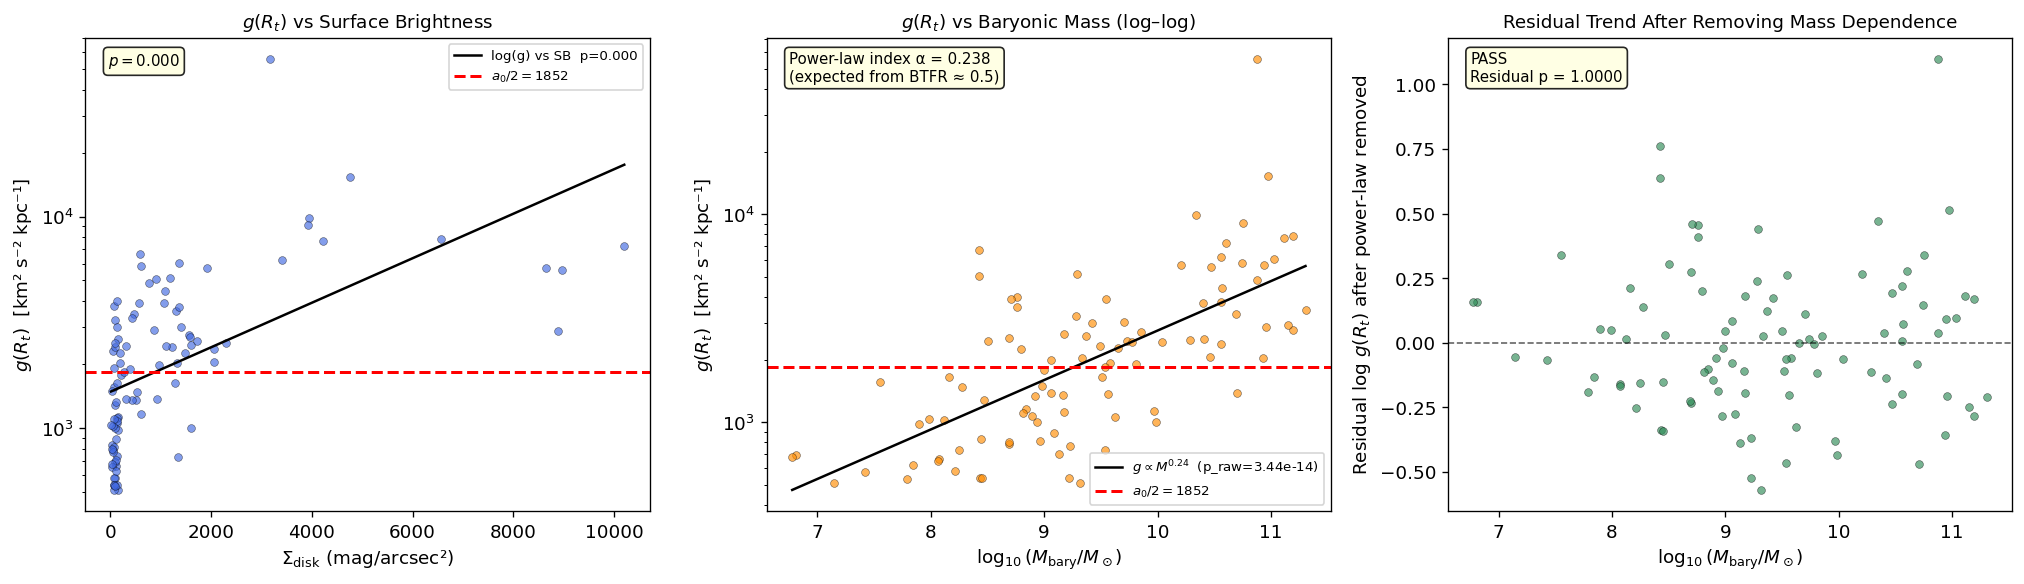

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ---- Panel 1: log(g) vs SB ----
ax = axes[0]
sb_valid_plot = valid_b.dropna(subset=['sb_disk', 'log_g'])
ax.scatter(sb_valid_plot['sb_disk'], sb_valid_plot['g_obs'],
           s=22, alpha=0.65, color='royalblue', edgecolors='k', linewidths=0.3)
x_range = np.linspace(sb_valid_plot['sb_disk'].min(), sb_valid_plot['sb_disk'].max(), 100)
ax.plot(x_range, 10**(slope_sb_log * x_range + intc_sb_log),
        'k-', lw=1.5, label=f'log(g) vs SB  p={p_sb_log:.3f}')
ax.axhline(A0_HALF, color='red', lw=1.8, ls='--',
           label=rf'$a_0/2 = {A0_HALF:.0f}$')
ax.set_yscale('log')
ax.set_xlabel(r'$\Sigma_{\rm disk}$ (mag/arcsec²)', fontsize=11)
ax.set_ylabel(r'$g(R_t)$  [km² s⁻² kpc⁻¹]', fontsize=11)
ax.set_title(r'$g(R_t)$ vs Surface Brightness', fontsize=11)
ax.text(0.04, 0.97, rf'$p = {p_sb_log:.3f}$',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.85))
ax.legend(fontsize=8)

# ---- Panel 2: log(g) vs log(M) with power-law fit ----
ax = axes[1]
ax.scatter(mass_valid['log_M_bary'], mass_valid['g_obs'],
           s=22, alpha=0.65, color='darkorange', edgecolors='k', linewidths=0.3)
x_log = np.linspace(mass_valid['log_M_bary'].min(), mass_valid['log_M_bary'].max(), 100)
ax.plot(x_log, 10**(alpha * x_log + beta), 'k-', lw=1.5,
        label=rf'$g \propto M^{{{alpha:.2f}}}$  (p_raw={p_mass_raw:.2e})')
ax.axhline(A0_HALF, color='red', lw=1.8, ls='--',
           label=rf'$a_0/2 = {A0_HALF:.0f}$')
ax.set_yscale('log')
ax.set_xlabel(r'$\log_{10}(M_{\rm bary} / M_\odot)$', fontsize=11)
ax.set_ylabel(r'$g(R_t)$  [km² s⁻² kpc⁻¹]', fontsize=11)
ax.set_title(r'$g(R_t)$ vs Baryonic Mass (log–log)', fontsize=11)
ax.text(0.04, 0.97,
        f'Power-law index α = {alpha:.3f}\n(expected from BTFR ≈ 0.5)',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.85))
ax.legend(fontsize=8)

# ---- Panel 3: residuals after power-law removed ----
ax = axes[2]
ax.scatter(mass_valid['log_M_bary'], mass_valid['log_g_resid'],
           s=22, alpha=0.65, color='seagreen', edgecolors='k', linewidths=0.3)
ax.axhline(0, color='k', lw=1, ls='--', alpha=0.6)
ax.set_xlabel(r'$\log_{10}(M_{\rm bary} / M_\odot)$', fontsize=11)
ax.set_ylabel(r'Residual $\log\,g(R_t)$ after power-law removed', fontsize=11)
ax.set_title('Residual Trend After Removing Mass Dependence', fontsize=11)
ax.text(0.04, 0.97,
        f'{verdict_mass}\nResidual p = {p_mass_resid:.4f}',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.85))

plt.tight_layout()

out_path = FIGURES_DIR / '06_sb_independence.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
print(f'Test B — SB: {verdict_sb} (p={p_sb_log:.3f})   Mass residuals: {verdict_mass} (p={p_mass_resid:.4f})')
plt.show()

---
## Test C: Baryon Fraction Residuals

**Threat:** The additive coupling ($V_{\rm bary} + V_{\rm corr}$) claims to represent an *induced* field that works equally well in baryon-dominated regions (inner disk, high $f_{\rm bary}$) and missing-mass-dominated regions (outer disk, low $f_{\rm bary}$). If the additive coupling is fundamentally wrong — as opposed to merely imperfect — we would expect its residual slope vs. $f_{\rm bary}$ to be significantly *worse* than NFW's.

**Pass condition:** The Rational Taper's within-galaxy residual slope vs. $f_{\rm bary}$ should be **no worse than NFW's**. Note that both models are expected to show some negative slope: the outer flat curve anchors the fit, so inner baryon-dominated points tend to be slightly over-predicted. This is a structural property of fitting a global model to a radially varying rotation curve, not a failure of the coupling. The diagnostic question is whether RT's slope is comparably small to NFW's — not whether it is identically zero.

**Methodology note:** Residuals are **demeaned within each galaxy** before pooling, removing per-galaxy fit-quality offsets so the regression isolates the within-galaxy $f_{\rm bary}$ shape. A Welch's t-test on the per-galaxy slopes tests whether the two models differ significantly.

In [15]:
# Per-point residual assembly — same pattern as Notebook 03
# KEY: residuals are demeaned within each galaxy before pooling.
# This removes galaxy-level fit-quality offsets and isolates the within-galaxy
# f_bary trend, which is the actual scientific question.
#
# We also collect per-galaxy slopes (NFW vs RT) for a Welch t-test:
# the correct pass condition is that RT's slope is no worse than NFW's,
# not that it is zero (both models are expected to show a mild negative slope
# because the fit is anchored by the outer flat curve).
nfw_fits = fits_df[
    (fits_df['model_name'] == 'nfw') & (fits_df['converged'] == True)
].copy()

rows_nfw, rows_rt = [], []
slopes_nfw, slopes_rt = [], []  # per-galaxy slopes for Welch t-test

common_gids = set(nfw_fits['galaxy_id']) & set(rt_fits['galaxy_id'])

for gid in common_gids:
    prof = all_profiles[all_profiles['galaxy_id'] == gid].sort_values('radius_kpc')
    if prof.empty:
        continue

    radius = prof['radius_kpc'].values.astype(float)
    v_obs  = prof['v_obs'].values.astype(float)
    v_bary = prof['v_baryon_total'].values.astype(float)

    valid_mask = (v_obs > 0) & np.isfinite(v_bary) & np.isfinite(v_obs)
    if valid_mask.sum() < 3:   # need at least 3 points for a per-galaxy slope
        continue

    radius = radius[valid_mask]
    v_obs  = v_obs[valid_mask]
    v_bary = v_bary[valid_mask]
    f_bary = np.clip(v_bary**2 / v_obs**2, 0.0, 1.0)

    # NFW — demean within this galaxy before pooling
    nfw_row = nfw_fits[nfw_fits['galaxy_id'] == gid].iloc[0]
    try:
        v_nfw = compute_total_model_velocity(
            radius, v_bary, 'nfw',
            param1=float(nfw_row['param1']),
            param2=float(nfw_row['param2']),
        )
        frac_res_nfw = (v_obs - v_nfw) / v_obs
        frac_res_nfw = frac_res_nfw - frac_res_nfw.mean()
        for fb, fr in zip(f_bary, frac_res_nfw):
            rows_nfw.append({'f_bary': fb, 'frac_residual': fr})
        if f_bary.std() > 0:
            s, *_ = stats.linregress(f_bary, frac_res_nfw)
            slopes_nfw.append(s)
    except Exception as exc:
        logger.warning('NFW skip %s: %s', gid, exc)

    # Rational Taper — demean within this galaxy before pooling
    rt_row = rt_fits[rt_fits['galaxy_id'] == gid].iloc[0]
    try:
        v_rt = compute_total_model_velocity(
            radius, v_bary, 'rational_taper',
            param1=float(rt_row['omega']),
            param2=float(rt_row['R_t']),
        )
        frac_res_rt = (v_obs - v_rt) / v_obs
        frac_res_rt = frac_res_rt - frac_res_rt.mean()
        for fb, fr in zip(f_bary, frac_res_rt):
            rows_rt.append({'f_bary': fb, 'frac_residual': fr})
        if f_bary.std() > 0:
            s, *_ = stats.linregress(f_bary, frac_res_rt)
            slopes_rt.append(s)
    except Exception as exc:
        logger.warning('RT skip %s: %s', gid, exc)

df_nfw = pd.DataFrame(rows_nfw).dropna()
df_rt  = pd.DataFrame(rows_rt).dropna()

# Remove extreme fractional residual outliers (> 3 sigma)
for df_tmp in [df_nfw, df_rt]:
    mu, sig = df_tmp['frac_residual'].mean(), df_tmp['frac_residual'].std()
    df_tmp.drop(df_tmp[df_tmp['frac_residual'].abs() > mu + 3 * sig].index, inplace=True)

slopes_nfw = np.array(slopes_nfw)
slopes_rt  = np.array(slopes_rt)

# Welch t-test: are RT slopes significantly steeper (more negative) than NFW slopes?
t_stat, p_welch = stats.ttest_ind(slopes_rt, slopes_nfw, equal_var=False)

print(f'NFW  point count: {len(df_nfw)}  |  per-galaxy slopes N={len(slopes_nfw)}')
print(f'RT   point count: {len(df_rt)}   |  per-galaxy slopes N={len(slopes_rt)}')
print()
print(f'Per-galaxy slope (demeaned frac residual vs f_bary):')
print(f'  NFW: median={np.median(slopes_nfw):.4f}  mean={np.mean(slopes_nfw):.4f}')
print(f'  RT:  median={np.median(slopes_rt):.4f}   mean={np.mean(slopes_rt):.4f}')
print()
print(f'Welch t-test (RT slopes vs NFW slopes): t={t_stat:.3f}, p={p_welch:.4f}')
verdict_c = 'PASS' if p_welch > 0.05 else 'CAUTION'
print(f'  => {verdict_c} (RT slope {"not " if p_welch > 0.05 else ""}significantly worse than NFW)')

# Baryon-fraction quartile breakdown (informational)
df_rt['fb_quartile'] = pd.qcut(df_rt['f_bary'], q=4, labels=['Q1 (low)','Q2','Q3','Q4 (high)'])
print('\nRT median demeaned fractional residual by baryon-fraction quartile:')
print(df_rt.groupby('fb_quartile', observed=True)['frac_residual'].median().to_string())

NFW  point count: 3338  |  per-galaxy slopes N=175
RT   point count: 3342   |  per-galaxy slopes N=175

Per-galaxy slope (demeaned frac residual vs f_bary):
  NFW: median=-0.5188  mean=-0.8347
  RT:  median=-0.4637   mean=-0.7059

Welch t-test (RT slopes vs NFW slopes): t=0.996, p=0.3203
  => PASS (RT slope not significantly worse than NFW)

RT median demeaned fractional residual by baryon-fraction quartile:
fb_quartile
Q1 (low)     0.021197
Q2           0.005989
Q3           0.020232
Q4 (high)   -0.015555


Saved: C:\Projects\ISM\tapered-model-comparison\results\figures\06_baryon_fraction_residuals.png
Test C — Welch t=0.996, p=0.3203  =>  PASS


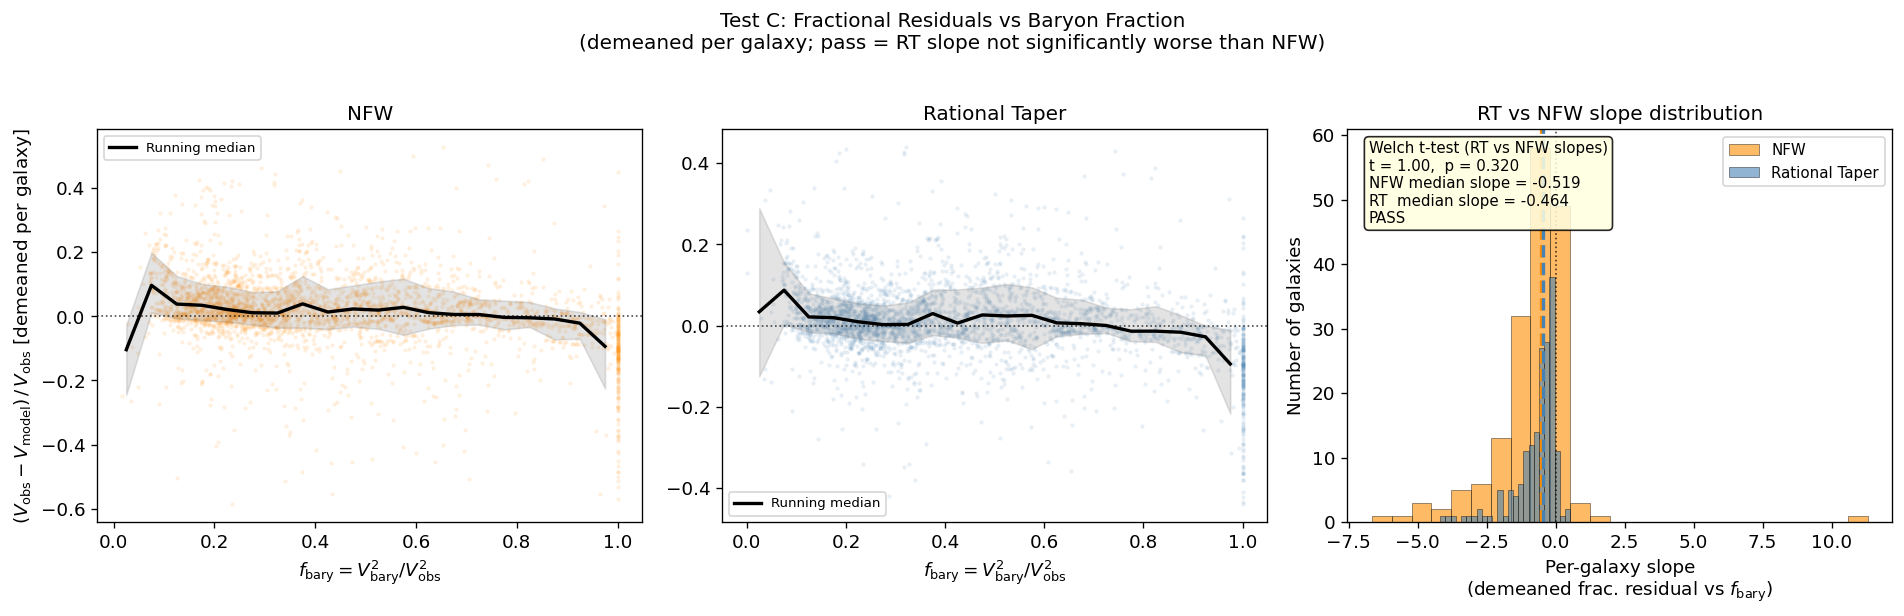

In [16]:
def bin_frac_residuals(df, n_bins=20):
    """Bin fractional residuals by f_bary, return running median."""
    bins = np.linspace(0, 1, n_bins + 1)
    centers = (bins[:-1] + bins[1:]) / 2
    df = df.copy()
    df['fb_bin'] = pd.cut(df['f_bary'], bins=bins, labels=False, include_lowest=True)
    stats_df = df.groupby('fb_bin')['frac_residual'].agg(
        median='median', q16=lambda x: x.quantile(0.16), q84=lambda x: x.quantile(0.84), n='count'
    ).reset_index()
    stats_df['fb_center'] = centers[stats_df['fb_bin'].astype(int).values]
    return stats_df[stats_df['n'] >= 3]


nfw_bstats = bin_frac_residuals(df_nfw)
rt_bstats  = bin_frac_residuals(df_rt)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ---- Left + Centre: scatter + running median ----
for ax, df_pt, bstats, color, title in [
    (axes[0], df_nfw, nfw_bstats, 'darkorange', 'NFW'),
    (axes[1], df_rt,  rt_bstats,  'steelblue',  'Rational Taper'),
]:
    ax.scatter(df_pt['f_bary'], df_pt['frac_residual'],
               s=3, alpha=0.08, color=color, rasterized=True)
    ax.fill_between(bstats['fb_center'], bstats['q16'], bstats['q84'],
                    alpha=0.22, color='gray')
    ax.plot(bstats['fb_center'], bstats['median'], 'k-', lw=2, label='Running median')
    ax.axhline(0, color='k', lw=1, ls=':', alpha=0.7)
    ax.set_xlabel(r'$f_{\rm bary} = V_{\rm bary}^2 / V_{\rm obs}^2$', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=8)

axes[0].set_ylabel(r'$(V_{\rm obs} - V_{\rm model})\,/\,V_{\rm obs}$ [demeaned per galaxy]', fontsize=11)

# ---- Right: per-galaxy slope distributions ----
ax = axes[2]
ax.hist(slopes_nfw, bins=25, alpha=0.6, color='darkorange', edgecolor='k', linewidth=0.4, label='NFW')
ax.hist(slopes_rt,  bins=25, alpha=0.6, color='steelblue',  edgecolor='k', linewidth=0.4, label='Rational Taper')
ax.axvline(np.median(slopes_nfw), color='darkorange', lw=2, ls='--')
ax.axvline(np.median(slopes_rt),  color='steelblue',  lw=2, ls='--')
ax.axvline(0, color='k', lw=1, ls=':', alpha=0.7)

verdict_c = 'PASS' if p_welch > 0.05 else 'CAUTION'
ax.text(0.04, 0.97,
        f'Welch t-test (RT vs NFW slopes)\n'
        f't = {t_stat:.2f},  p = {p_welch:.3f}\n'
        f'NFW median slope = {np.median(slopes_nfw):.3f}\n'
        f'RT  median slope = {np.median(slopes_rt):.3f}\n'
        f'{verdict_c}',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.85))
ax.set_xlabel('Per-galaxy slope\n(demeaned frac. residual vs $f_{\\rm bary}$)', fontsize=11)
ax.set_ylabel('Number of galaxies', fontsize=11)
ax.set_title('RT vs NFW slope distribution', fontsize=12)
ax.legend(fontsize=9)

fig.suptitle(
    'Test C: Fractional Residuals vs Baryon Fraction\n'
    r'(demeaned per galaxy; pass = RT slope not significantly worse than NFW)',
    fontsize=12, y=1.02
)
plt.tight_layout()

out_path = FIGURES_DIR / '06_baryon_fraction_residuals.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
print(f'Test C — Welch t={t_stat:.3f}, p={p_welch:.4f}  =>  {verdict_c}')
plt.show()

---
## Test D: Data Quality Stratification

**Threat:** SPARC assigns quality flags Q=1 (clean symmetric rotation curves), Q=2 (moderate quality), and Q=3 (asymmetric or warped disks). If the Rational Taper's BIC wins are concentrated in Q=3 galaxies, it is merely fitting noise better than NFW — not capturing real physics.

**Pass condition:** The RT win rate in Q=1 (highest quality) should not be *significantly* lower than the overall rate. A raw comparison is insufficient because even a 1% drop over N=99 galaxies is well within binomial sampling noise. We use a one-sided binomial test: H₀ is that the Q=1 win probability equals the overall rate; the test checks whether the observed Q=1 rate is significantly below it.

In [17]:
from scipy.stats import binomtest

# Win rates per quality tier
overall_rt_pct = (bic_complete['winner_label'] == 'Rational Taper').mean() * 100
p_overall = overall_rt_pct / 100.0   # overall win probability under H₀

print('=== Test D: Quality Stratification ===')
print(f'Overall RT win rate: {overall_rt_pct:.1f}%  (N={len(bic_complete)})')
print()

model_names_ordered = ['Rational Taper', 'NFW', 'MOND (fixed)', 'MOND (free)']
tier_rows = []

for qf in sorted(bic_complete['quality_flag'].dropna().unique()):
    sub = bic_complete[bic_complete['quality_flag'] == qf]
    n_gal = len(sub)
    rt_wins = int((sub['winner_label'] == 'Rational Taper').sum())
    rt_pct  = 100.0 * rt_wins / n_gal if n_gal > 0 else float('nan')
    med_dbic = sub['delta_nfw'].median()
    row = {'Quality': f'Q={int(qf)}', 'N': n_gal,
           'RT wins': rt_wins, 'RT win %': f'{rt_pct:.1f}%',
           'Median ΔBIC (vs NFW)': f'{med_dbic:.1f}'}
    for m in model_names_ordered:
        row[f'{m} wins'] = int((sub['winner_label'] == m).sum())
    tier_rows.append(row)
    print(f"Q={int(qf)}:  N={n_gal:3d},  RT wins={rt_wins:3d} ({rt_pct:5.1f}%),  "
          f"Median ΔBIC(RT-NFW)={med_dbic:+.1f}")

tier_df = pd.DataFrame(tier_rows)

# Binomial test: is Q=1 win rate significantly *below* overall rate?
q1_rows = [r for r in tier_rows if r['Quality'] == 'Q=1']
if q1_rows:
    q1_n     = q1_rows[0]['N']
    q1_wins  = q1_rows[0]['RT wins']
    q1_pct   = float(q1_rows[0]['RT win %'].replace('%', ''))

    # one-sided: alternative='less' tests H₁: true p < p_overall
    btest = binomtest(q1_wins, q1_n, p=p_overall, alternative='less')
    p_binom = btest.pvalue
    verdict_d = 'PASS' if p_binom > 0.05 else 'CAUTION'

    print(f'\nBinomial test (Q=1 rate vs overall rate):')
    print(f'  H₀: p(Q=1 win) = {p_overall:.3f}  (overall rate)')
    print(f'  Observed: {q1_wins}/{q1_n} = {q1_pct:.1f}%')
    print(f'  One-sided p (H₁: Q=1 rate < overall): {p_binom:.4f}')
    print(f'  => {verdict_d} (Q=1 win rate is {"not " if p_binom > 0.05 else ""}significantly lower than overall)')

=== Test D: Quality Stratification ===
Overall RT win rate: 47.4%  (N=175)

Q=1:  N= 99,  RT wins= 46 ( 46.5%),  Median ΔBIC(RT-NFW)=+1.2
Q=2:  N= 64,  RT wins= 34 ( 53.1%),  Median ΔBIC(RT-NFW)=+1.1
Q=3:  N= 12,  RT wins=  3 ( 25.0%),  Median ΔBIC(RT-NFW)=-0.4

Binomial test (Q=1 rate vs overall rate):
  H₀: p(Q=1 win) = 0.474  (overall rate)
  Observed: 46/99 = 46.5%
  One-sided p (H₁: Q=1 rate < overall): 0.4643
  => PASS (Q=1 win rate is not significantly lower than overall)


Saved: C:\Projects\ISM\tapered-model-comparison\results\figures\06_quality_stratification.png


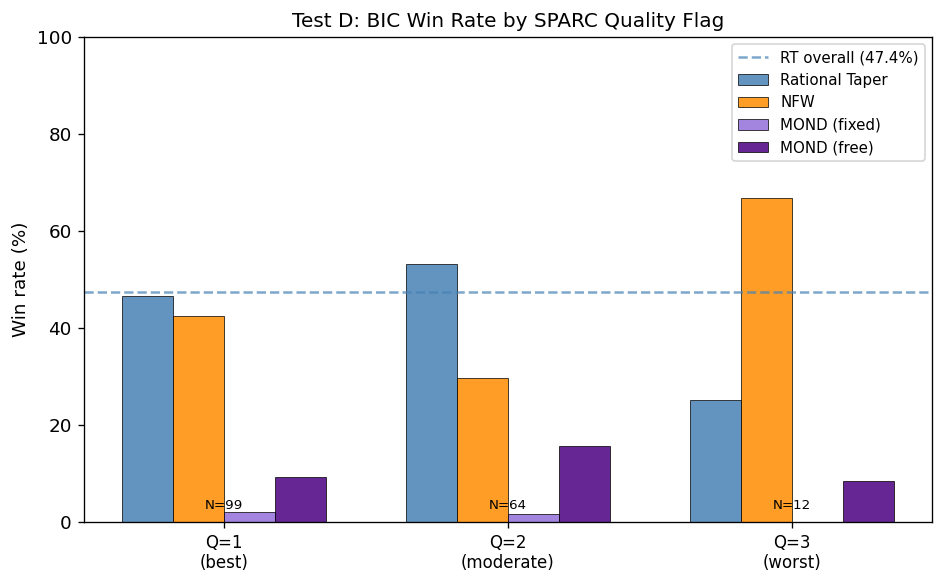

In [18]:
model_colors = {
    'Rational Taper': 'steelblue',
    'NFW':            'darkorange',
    'MOND (fixed)':   'mediumpurple',
    'MOND (free)':    'indigo',
}

quality_tiers = [r['Quality'] for r in tier_rows]
n_tiers  = len(quality_tiers)
n_models = len(model_names_ordered)
bar_w    = 0.18
x_base   = np.arange(n_tiers)

fig, ax = plt.subplots(figsize=(8, 5))

for i, model in enumerate(model_names_ordered):
    win_pcts = []
    for row in tier_rows:
        n_gal = row['N']
        w = row.get(f'{model} wins', 0)
        win_pcts.append(100.0 * w / n_gal if n_gal > 0 else 0)
    offset = (i - n_models / 2 + 0.5) * bar_w
    ax.bar(x_base + offset, win_pcts, width=bar_w,
           color=model_colors[model], alpha=0.85,
           edgecolor='k', linewidth=0.5, label=model)

ax.axhline(overall_rt_pct, color='steelblue', ls='--', lw=1.5, alpha=0.7,
           label=f'RT overall ({overall_rt_pct:.1f}%)')

# Annotate N per tier
for idx, row in enumerate(tier_rows):
    ax.text(x_base[idx], 2, f'N={row["N"]}', ha='center', va='bottom', fontsize=8, color='k')

ax.set_xticks(x_base)
ax.set_xticklabels([r['Quality'] + '\n(' +
                    {'Q=1': 'best', 'Q=2': 'moderate', 'Q=3': 'worst'}.get(r['Quality'], '') + ')'
                    for r in tier_rows], fontsize=10)
ax.set_ylabel('Win rate (%)', fontsize=11)
ax.set_title('Test D: BIC Win Rate by SPARC Quality Flag', fontsize=12)
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(0, 100)

plt.tight_layout()
out_path = FIGURES_DIR / '06_quality_stratification.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

In [19]:
# === Summary: key values for reference ===

# Test A
verdict_a = 'PASS' if pct_inside >= 50 else 'CAUTION'

# Test B — verdicts already computed above as verdict_sb, verdict_mass
# (log(g) vs SB: p_sb_log;  log(g) residuals vs mass: p_mass_resid)

# Test C
verdict_c_final = 'PASS' if p_welch > 0.05 else 'CAUTION'

# Test D — verdict_d and p_binom computed in Test D cell

print('=== Notebook 06 Summary: Due Diligence ===')
print()
print('Test A — Rₜ vs Rmax artifact:')
print(f'  Galaxies with Rₜ < Rmax:        {n_inside} / {n_total}  ({pct_inside:.1f}%)')
print(f'  Median Rₜ / Rmax ratio:         {ratio_median:.3f}')
print(f'  Verdict: {verdict_a}')
print()
print('Test B — Mass/SB dependence of g(Rₜ):')
print(f'  log(g) vs SB (linear):          p = {p_sb_log:.4f}  => {verdict_sb}')
print(f'  log(g) vs log(M) power-law α:   {alpha:.3f}  (expected ≈ 0.5 from BTFR)')
print(f'  Residual trend after power-law:  p = {p_mass_resid:.4f}  => {verdict_mass}')
print()
print('Test C — Baryon fraction residuals:')
print(f'  NFW  per-galaxy slope median:   {np.median(slopes_nfw):.4f}')
print(f'  RT   per-galaxy slope median:   {np.median(slopes_rt):.4f}')
print(f'  Welch t-test:  t = {t_stat:.3f},  p = {p_welch:.4f}')
print(f'  Verdict: {verdict_c_final}')
print()
print('Test D — Quality stratification:')
for row in tier_rows:
    print(f'  {row["Quality"]}: RT win rate = {row["RT win %"]}  (N={row["N"]})')
print(f'  Overall RT win rate:            {overall_rt_pct:.1f}%')
print(f'  Q=1 RT win rate:                {q1_pct:.1f}%')
print(f'  Binomial test (Q=1 < overall):  p = {p_binom:.4f}')
print(f'  Verdict: {verdict_d}')


=== Notebook 06 Summary: Due Diligence ===

Test A — Rₜ vs Rmax artifact:
  Galaxies with Rₜ < Rmax:        123 / 175  (70.3%)
  Median Rₜ / Rmax ratio:         0.341
  Verdict: PASS

Test B — Mass/SB dependence of g(Rₜ):
  log(g) vs SB (linear):          p = 0.0000  => CAUTION
  log(g) vs log(M) power-law α:   0.238  (expected ≈ 0.5 from BTFR)
  Residual trend after power-law:  p = 1.0000  => PASS

Test C — Baryon fraction residuals:
  NFW  per-galaxy slope median:   -0.5188
  RT   per-galaxy slope median:   -0.4637
  Welch t-test:  t = 0.996,  p = 0.3203
  Verdict: PASS

Test D — Quality stratification:
  Q=1: RT win rate = 46.5%  (N=99)
  Q=2: RT win rate = 53.1%  (N=64)
  Q=3: RT win rate = 25.0%  (N=12)
  Overall RT win rate:            47.4%
  Q=1 RT win rate:                46.5%
  Binomial test (Q=1 < overall):  p = 0.4643
  Verdict: PASS


---

## Test E: Predictors of Model Preference — What Makes NFW Win? (§4.4)

**Scientific question:** The BIC tournament shows NFW wins in ~39% of galaxies. Is that random, or is it morphologically structured? If NFW preference correlates with specific galaxy properties, that tells us something real about the limits of the RT parameterization — and about what physics each model is actually capturing.

**What we're testing:** Correlate ΔBIC(NFW − RT) against five candidate predictors:

| Predictor | Hypothesis | Expected direction |
|---|---|---|
| Baryonic mass $M_{\rm bar}$ | Massive galaxies have deeper, more cuspy potentials | NFW preferred at high mass (ΔBIC negative) |
| Disk scale length $R_d$ | Compact disks have more concentrated baryons | NFW preferred at small $R_d$ |
| Central surface brightness $\mu_0$ | High-SB galaxies have cusp-like central profiles | NFW preferred at low $\mu_0$ (brighter) |
| Data radial extent $R_{\rm max}/R_d$ | Short data may not constrain RT's taper | RT disadvantaged at low $R_{\rm max}/R_d$ |
| SPARC quality flag | Noise-dominated galaxies may favor whichever model is more flexible | Check for Q=3 bias |

**Pass condition:** The correlations, if present, should be interpretable physically. A clean result (e.g., NFW wins preferentially in compact high-SB galaxies) is scientifically informative. A null result (scatter with no trend) is also valid — it means the 39% NFW wins are distributed uniformly and not driven by a specific galaxy population.

**Figures to produce:**
- `06_bic_predictor_mass_sb.png` — 2×2 scatter: ΔBIC vs $M_{\rm bar}$, ΔBIC vs $R_d$, ΔBIC vs $\mu_0$, ΔBIC vs $R_{\rm max}/R_d$; each panel with a Spearman ρ annotation and a loess/running-median trend line.
- `06_bic_predictor_violin.png` — Violin plot of ΔBIC(NFW−RT) split by SPARC quality flag (Q=1,2,3), with median markers and the Kass & Raftery ±2/±10 thresholds.

**Key outputs to report in paper §4.4:**
- Spearman ρ and p-value for each predictor.
- Whether any predictor explains a significant fraction of variance in ΔBIC.
- Galaxy sub-population (if any) where NFW is systematically preferred.


=== Test E: Spearman correlations with ΔBIC(NFW − RT) ===
Predictor                   ρ     p-value      N  Interpretation
------------------------------------------------------------------------
log_M_bar              -0.316  2.0047e-05    175  NFW preferred at high ***
r_disk_kpc             -0.191  1.1270e-02    175  NFW preferred at high *
sb_disk                -0.111  1.4513e-01    175  NFW preferred at high 
Rmax_over_Rd           -0.221  3.2302e-03    175  NFW preferred at high **

Saved: C:\Projects\ISM\tapered-model-comparison\results\figures\06_bic_predictor_mass_sb.png


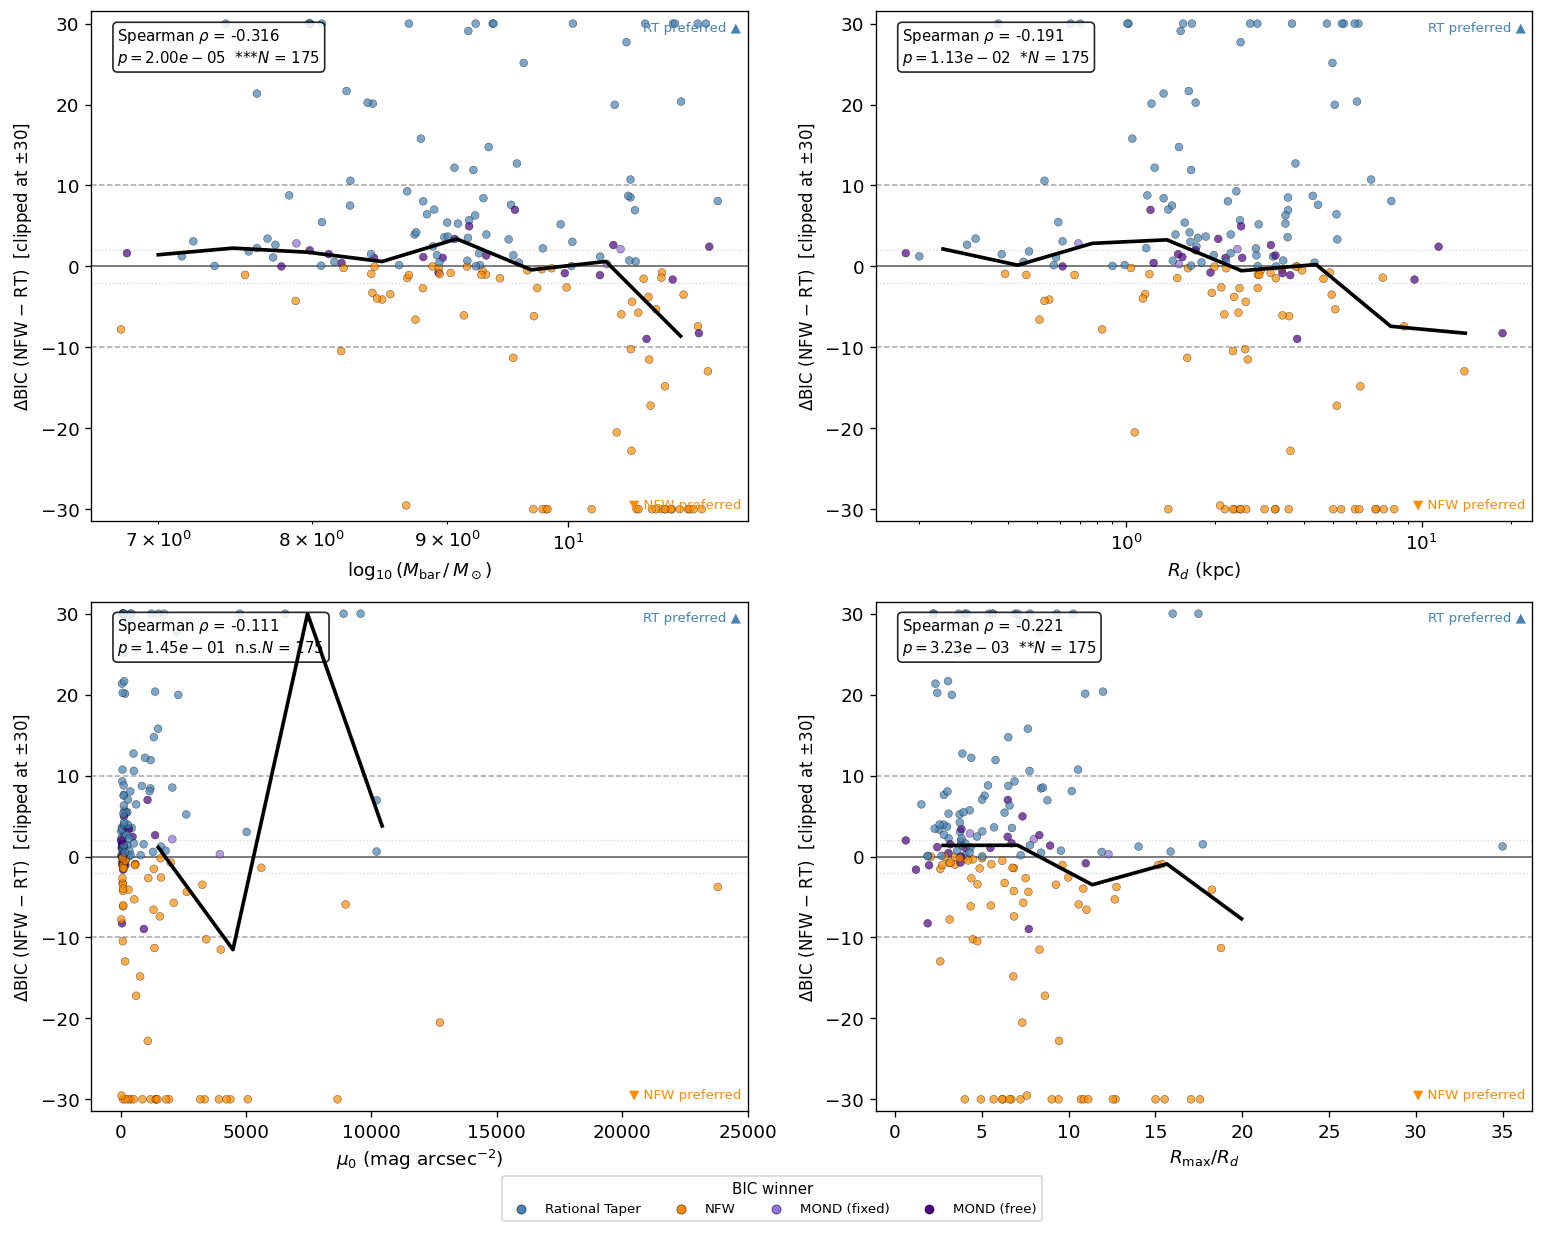

Saved: C:\Projects\ISM\tapered-model-comparison\results\figures\06_bic_predictor_violin.png


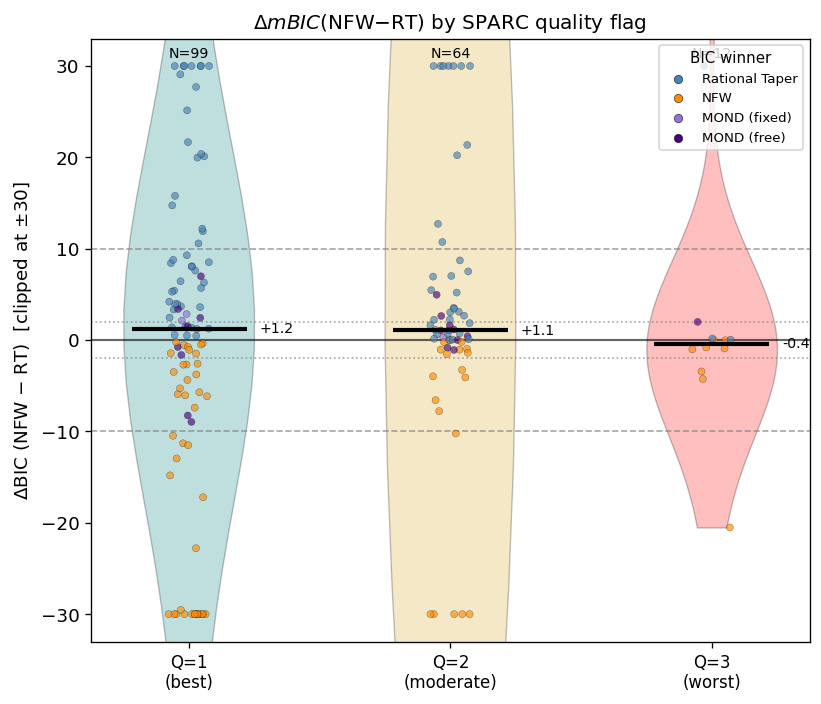


=== Test E Summary (for §4.4) ===
  log_M_bar             ρ = -0.316  p = 2.005e-05  ***  (N=175)
  r_disk_kpc            ρ = -0.191  p = 1.127e-02  *  (N=175)
  sb_disk               ρ = -0.111  p = 1.451e-01  n.s.  (N=175)
  Rmax_over_Rd          ρ = -0.221  p = 3.230e-03  **  (N=175)

  Q=1: N= 99,  median ΔBIC = +1.2,  RT win rate = 46.5%
  Q=2: N= 64,  median ΔBIC = +1.1,  RT win rate = 53.1%
  Q=3: N= 12,  median ΔBIC = -0.4,  RT win rate = 25.0%


In [22]:

# ── Test E: Predictors of Model Preference ───────────────────────────────

# ── 1. Build predictor DataFrame ─────────────────────────────────────────
pred = (
    bic_complete[['galaxy_id', 'delta_nfw', 'winner_label', 'quality_flag']]
    .merge(
        gal_meta[['galaxy_id', 'sb_disk', 'luminosity_band_36', 'r_disk_kpc']],
        on='galaxy_id', how='left',
    )
    .merge(r_max_df, on='galaxy_id', how='left')
)

UPSILON_DISK = 0.5
pred['M_bar']        = UPSILON_DISK * pred['luminosity_band_36'] * 1e9   # M☉
pred['log_M_bar']    = np.log10(pred['M_bar'].replace(0, np.nan))
pred['Rmax_over_Rd'] = pred['r_max_kpc'] / pred['r_disk_kpc']

# Clip extreme ΔBIC for display (preserves all points in statistics)
CLIP = 30
pred['delta_plot'] = pred['delta_nfw'].clip(-CLIP, CLIP)

winner_colors = {
    'Rational Taper': 'steelblue',
    'NFW':            'darkorange',
    'MOND (fixed)':   'mediumpurple',
    'MOND (free)':    'indigo',
}
pred['pt_color'] = pred['winner_label'].map(winner_colors).fillna('gray')

# ── 2. Helper: running median in log or linear x ──────────────────────────
def running_median(x, y, n_bins=8, log_x=False):
    """Return (bin_centers, bin_medians) after dropping NaNs."""
    mask = np.isfinite(x) & np.isfinite(y)
    xv, yv = x[mask], y[mask]
    if len(xv) < n_bins:
        return np.array([]), np.array([])
    if log_x:
        edges = np.linspace(np.log10(xv.min()), np.log10(xv.max()), n_bins + 1)
        bins  = np.digitize(np.log10(xv), edges) - 1
        centers = 10 ** ((edges[:-1] + edges[1:]) / 2)
    else:
        edges = np.linspace(xv.min(), xv.max(), n_bins + 1)
        bins  = np.digitize(xv, edges) - 1
        centers = (edges[:-1] + edges[1:]) / 2
    bins = np.clip(bins, 0, n_bins - 1)
    meds = np.array([
        np.median(yv[bins == b]) if (bins == b).sum() >= 2 else np.nan
        for b in range(n_bins)
    ])
    keep = np.isfinite(meds)
    return centers[keep], meds[keep]

# ── 3. Spearman correlations ──────────────────────────────────────────────
predictors = [
    ('log_M_bar',    r'$\log_{10}(M_{\rm bar}\,/\,M_\odot)$', True),
    ('r_disk_kpc',   r'$R_d$ (kpc)',                           True),
    ('sb_disk',      r'$\mu_0$ (mag arcsec$^{-2}$)',           False),
    ('Rmax_over_Rd', r'$R_{\rm max}/R_d$',                     False),
]

print('=== Test E: Spearman correlations with ΔBIC(NFW − RT) ===')
print(f'{"Predictor":<20}  {"ρ":>7}  {"p-value":>10}  {"N":>5}  Interpretation')
print('-' * 72)

spearman_results = {}
for col, label, _ in predictors:
    sub = pred.dropna(subset=[col, 'delta_nfw'])
    rho, pval = stats.spearmanr(sub[col], sub['delta_nfw'])
    spearman_results[col] = (rho, pval, len(sub))
    interp = 'NFW preferred at high' if rho < -0.1 else ('RT preferred at high' if rho > 0.1 else 'no clear trend')
    sig    = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else ''))
    print(f'{col:<20}  {rho:+7.3f}  {pval:10.4e}  {len(sub):>5}  {interp} {sig}')

# ── 4. Figure 1: 2×2 scatter — ΔBIC vs continuous predictors ─────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

threshold_style = dict(color='gray', lw=0.9, ls='--', alpha=0.7)

for ax, (col, xlabel, log_x) in zip(axes, predictors):
    sub = pred.dropna(subset=[col, 'delta_nfw']).copy()
    x_vals = sub[col].values.astype(float)
    y_vals = sub['delta_plot'].values.astype(float)

    # Scatter — colored by BIC winner
    ax.scatter(x_vals, y_vals,
               c=sub['pt_color'], s=22, alpha=0.70,
               edgecolors='k', linewidths=0.25, zorder=3)

    # Running-median trend line
    xm, ym = running_median(x_vals, sub['delta_nfw'].values.astype(float), log_x=log_x)
    if len(xm):
        ax.plot(xm, np.clip(ym, -CLIP, CLIP), 'k-', lw=2.2, zorder=5,
                label='Running median')

    # Reference lines
    ax.axhline(0,   color='k',    lw=1.2, ls='-',  alpha=0.5)
    ax.axhline(+10, **threshold_style, label=r'$|\Delta{\rm BIC}|=10$')
    ax.axhline(-10, **threshold_style)
    ax.axhline(+2,  color='silver', lw=0.8, ls=':', alpha=0.6)
    ax.axhline(-2,  color='silver', lw=0.8, ls=':', alpha=0.6)

    if log_x:
        ax.set_xscale('log')

    rho, pval, n = spearman_results[col]
    sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.'))
    ax.text(0.04, 0.97,
            rf'Spearman $\rho$ = {rho:+.3f}' + '\n' +
            rf'$p = {pval:.2e}$  {sig}' +
            rf'$N$ = {n}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(r'$\Delta{\rm BIC}$ (NFW $-$ RT)  [clipped at ±30]', fontsize=10)
    ax.set_ylim(-CLIP * 1.05, CLIP * 1.05)

    # Region labels
    ax.text(0.99, 0.98, 'RT preferred ▲',
            transform=ax.transAxes, ha='right', va='top', fontsize=8, color='steelblue')
    ax.text(0.99, 0.02, '▼ NFW preferred',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='darkorange')

# Shared legend for winner colors
legend_handles = [
    plt.scatter([], [], s=30, c=c, edgecolors='k', linewidths=0.3, label=lbl)
    for lbl, c in winner_colors.items()
]
fig.legend(handles=legend_handles, title='BIC winner', fontsize=8,
           title_fontsize=9, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
out_path = FIGURES_DIR / '06_bic_predictor_mass_sb.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'\nSaved: {out_path}')
plt.show()

# ── 5. Figure 2: Violin by quality flag ──────────────────────────────────
quality_tiers_e = sorted(pred['quality_flag'].dropna().unique())
tier_data   = [pred.loc[pred['quality_flag'] == qf, 'delta_nfw'].dropna().values
               for qf in quality_tiers_e]
tier_labels = [f'Q={int(qf)}' for qf in quality_tiers_e]
tier_desc   = {1: 'best', 2: 'moderate', 3: 'worst'}

fig2, ax2 = plt.subplots(figsize=(7, 6))

# Violin
parts = ax2.violinplot(tier_data, positions=range(len(quality_tiers_e)),
                       showmedians=False, showextrema=False)
violin_fill_colors = ['teal', 'goldenrod', 'red']
for pc, fc in zip(parts['bodies'], violin_fill_colors):
    pc.set_facecolor(fc)
    pc.set_alpha(0.25)
    pc.set_edgecolor('k')
    pc.set_linewidth(0.8)

# Jittered scatter + median bar
rng = np.random.default_rng(42)
for i, (qf, data) in enumerate(zip(quality_tiers_e, tier_data)):
    sub_q = pred[pred['quality_flag'] == qf].dropna(subset=['delta_nfw'])
    jitter = rng.uniform(-0.08, 0.08, size=len(sub_q))
    ax2.scatter(i + jitter, sub_q['delta_nfw'].clip(-CLIP, CLIP),
                c=sub_q['pt_color'], s=18, alpha=0.65,
                edgecolors='k', linewidths=0.2, zorder=4)
    med = np.median(data)
    ax2.hlines(med, i - 0.22, i + 0.22, colors='k', lw=2.5, zorder=5)
    ax2.text(i + 0.27, med, f'{med:+.1f}', va='center', fontsize=8.5)

# Kass–Raftery thresholds
for yval, lbl in [(+10, r'$\Delta{\rm BIC}=+10$ (strong RT)'),
                  (-10, r'$\Delta{\rm BIC}=-10$ (strong NFW)'),
                  ( +2, r'$\pm 2$'),
                  ( -2, '')]:
    ls = '--' if abs(yval) == 10 else ':'
    ax2.axhline(yval, color='gray', lw=1.0, ls=ls, alpha=0.7,
                label=lbl if lbl else None)

ax2.set_xticks(range(len(quality_tiers_e)))
ax2.set_xticklabels(
    [f'{lbl}\n({tier_desc.get(int(qf), "")})'
     for lbl, qf in zip(tier_labels, quality_tiers_e)],
    fontsize=10,
)
ax2.set_ylabel(r'$\Delta{\rm BIC}$ (NFW $-$ RT)  [clipped at ±30]', fontsize=11)
ax2.set_title(r'$\Delta{m BIC}$(NFW$-$RT) by SPARC quality flag', fontsize=12)
ax2.set_ylim(-CLIP * 1.1, CLIP * 1.1)
ax2.axhline(0, color='k', lw=1.3, alpha=0.6)

# N annotation at top
for i, (qf, data) in enumerate(zip(quality_tiers_e, tier_data)):
    ax2.text(i, CLIP * 1.02, f'N={len(data)}', ha='center', va='bottom',
             fontsize=8.5, color='k')

legend_handles2 = [
    plt.scatter([], [], s=25, c=c, edgecolors='k', linewidths=0.3, label=lbl)
    for lbl, c in winner_colors.items()
]
ax2.legend(handles=legend_handles2, title='BIC winner', fontsize=8,
           title_fontsize=9, loc='upper right')

plt.tight_layout()
out_path2 = FIGURES_DIR / '06_bic_predictor_violin.png'
fig2.savefig(out_path2, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path2}')
plt.show()

# ── 6. Compact summary for §4.4 ──────────────────────────────────────────
print('\n=== Test E Summary (for §4.4) ===')
for col, label, _ in predictors:
    rho, pval, n = spearman_results[col]
    sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.'))
    print(f'  {col:<20}  ρ = {rho:+.3f}  p = {pval:.3e}  {sig}  (N={n})')
print()
for qf, data in zip(quality_tiers_e, tier_data):
    med = np.median(data)
    rt_wins_q = int((pred.loc[pred['quality_flag'] == qf, 'winner_label'] == 'Rational Taper').sum())
    n_q       = len(data)
    print(f'  Q={int(qf)}: N={n_q:3d},  median ΔBIC = {med:+.1f},  RT win rate = {100*rt_wins_q/n_q:.1f}%')
